In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scienceplots
import colormaps as cmaps

from nanonets import Simulation
from nanonets.utils import load_simulation_results
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 320
V_INPUT     = np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS, endpoint=False)
V_I_PLOT    = 1000*V_INPUT
T_VALS      = [1,2,4,8,16,32,64,128,256]
# PATH        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/temperature/"
PATH        = "/home/j/j_mens07/bagheera/data/1_funding_period/iv_curves/temperature/"

### IV-Curves at Cg=0.28

In [3]:
data = {T : pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=8_{T}.csv").sort_values(by='E0',ignore_index=True) for T in T_VALS}

In [4]:
N_E  = 8
n    = 9
topo = {"Nx": n, "Ny": n,
        "e_pos" : [[int((n-1)/2),0],[0,0],[n-1,0],[0,int((n-1)/2)],
        [n-1,int((n)/2)],[0,n-1],[n-1,n-1],[int((n)/2),(n-1)]],
        "electrode_type" : ['constant']*N_E}
sim_c = Simulation(topo)
sim_c.build_conductance_matrix()
sim_c.init_transfer_coeffs()
G_eff = sim_c.get_transfer_coeffs()[0]
I_ohm = G_eff * V_INPUT
y_theory = I_ohm

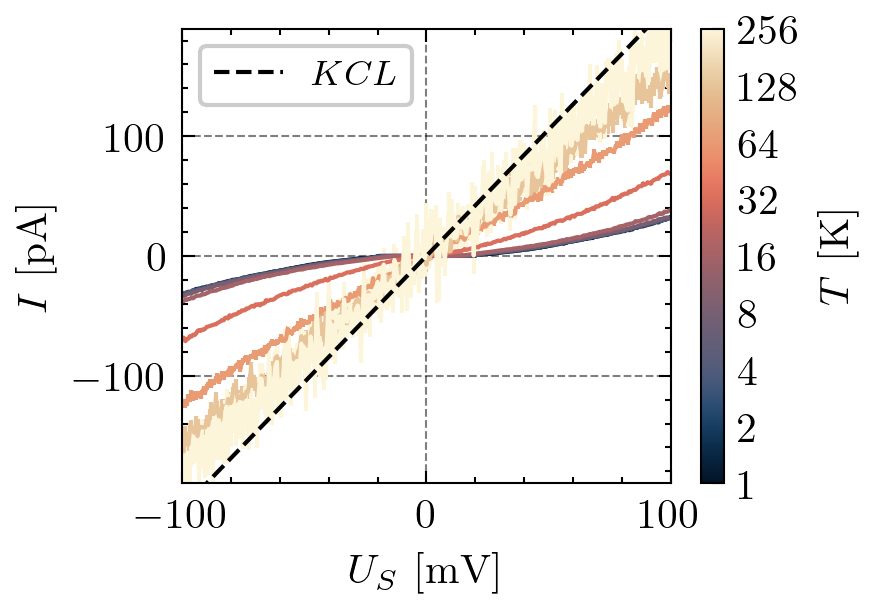

In [8]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.LogNorm(vmin=T_VALS[0],vmax=T_VALS[-1])
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, T in enumerate(T_VALS):
    df  = data[T].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmaps.lipari(norm(T)))

_   = ax.plot(V_I_PLOT, I_ohm*1e12, zorder=10, color='black', label='$KCL$', ls='--')
_   = ax.legend(fontsize='small')
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-100,100)
_   = ax.set_ylim(-190,190)

sm      = plt.cm.ScalarMappable(cmap=cmaps.lipari, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$T~[\mathrm{K}]$")

cbar.ax.yaxis.set_major_formatter(ScalarFormatter())
cbar.ax.yaxis.get_major_formatter().set_scientific(False)
cbar.ax.yaxis.get_major_formatter().set_useOffset(False)
_ = cbar.set_ticks(T_VALS)

fig.savefig(f"plots/svg/network_iv_curves_temperature.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_temperature.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_temperature.png", transparent=False)

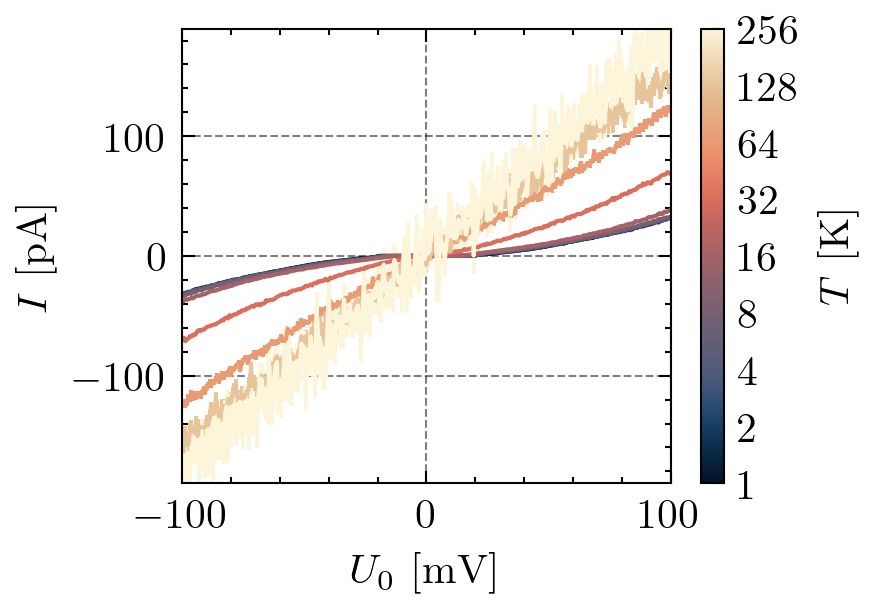

In [15]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.LogNorm(vmin=T_VALS[0],vmax=T_VALS[-1])
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, T in enumerate(T_VALS):
    df  = data[T].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmaps.lipari(norm(T)))

# _   = ax.plot(V_I_PLOT, I_ohm*1e12, zorder=10, color='black', label='$KCL$', ls='--')
# _   = ax.legend(fontsize='small')
_   = ax.set_xlabel("$U_0~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-100,100)
_   = ax.set_ylim(-190,190)

sm      = plt.cm.ScalarMappable(cmap=cmaps.lipari, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$T~[\mathrm{K}]$")

cbar.ax.yaxis.set_major_formatter(ScalarFormatter())
cbar.ax.yaxis.get_major_formatter().set_scientific(False)
cbar.ax.yaxis.get_major_formatter().set_useOffset(False)
_ = cbar.set_ticks(T_VALS)

fig.savefig(f"plots/svg/network_iv_curves_temperature_paper.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_temperature_paper.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_temperature_paper.png", transparent=False)

In [12]:
KB_MEV = 8.617e-2
window = 5
center = 160

def linear_iv(V, G, I_0):
    return G * V + I_0

g_zero  = []
g_err   = []

for i, T in enumerate(T_VALS):
    df  = data[T].copy().sort_values(by='E0')
    x   = df['E0'].values * 1000
    y   = df['Observable'].values * 1e-15
    y_e = df['Error'].values * 1e-15

    V_window = x[center-window : center+window+1]
    I_window = y[center-window : center+window+1]
    I_err_window = y_e[center-window : center+window+1]
    
    # Safety catch: if KMC returns exactly 0 error (no jumps), replace with a tiny number to avoid division by zero
    I_err_safe = np.where(I_err_window == 0, 1e-15, I_err_window)

    # Fit the linear I-V window, weighted by the KMC standard error!
    popt_linear, pcov_linear = curve_fit(linear_iv, V_window, I_window, sigma=I_err_safe, absolute_sigma=True)
    
    G_val = popt_linear[0]
    G_variance = pcov_linear[0, 0] 
    
    g_zero.append(G_val)
    g_err.append(np.sqrt(np.abs(G_variance)))

g_zero = np.array(g_zero)
g_err = np.array(g_err)

# Arrhenius function
def func(x, a, b):
    return a * np.exp(-b * x / KB_MEV)

# Filter the temperature range
valid_idx   = (np.array(T_VALS) > 0) & (np.array(T_VALS) < np.inf)
T_fit       = np.array(T_VALS)[valid_idx]
G_fit       = g_zero[valid_idx]
G_fit_err   = g_err[valid_idx]
inv_T_fit   = 1.0 / T_fit

# 3. Fit the Arrhenius curve, weighted by the conductance errors!
# p0 provides the initial guess: [G_infinity_guess, Ea_guess_in_meV]
popt, pcov  = curve_fit(func, inv_T_fit, G_fit, 
                        sigma=G_fit_err, absolute_sigma=True, 
                        p0=[1e-9, 15.0], maxfev=10000)

G_inf_est   = popt[0]
Ea_est      = popt[1]

print(f"Extracted Activation Energy Ea = {Ea_est:.2f} meV")

Extracted Activation Energy Ea = 12.29 meV


/tmp/ipykernel_20868/1106082559.py:38: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x / KB_MEV)


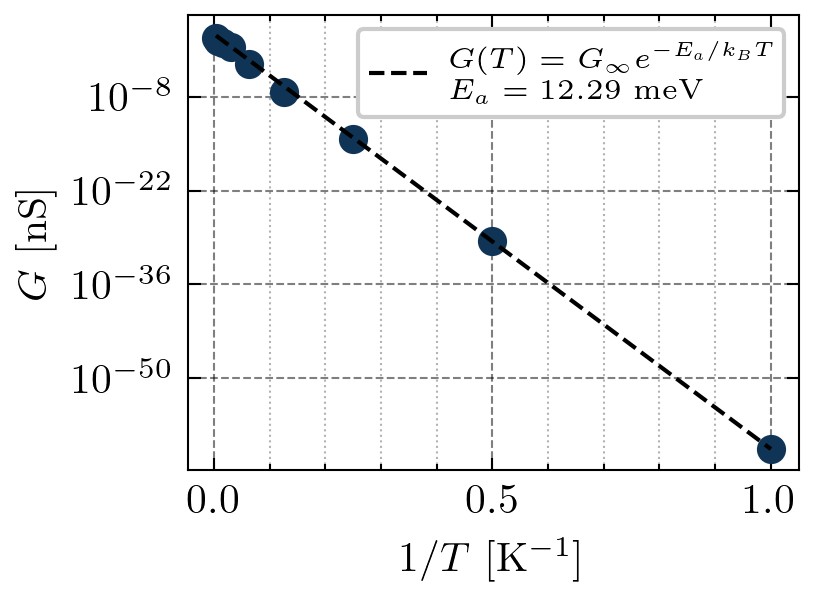

In [14]:
# Assuming g_zero and g_err are in Siemens (S). Convert to nano-Siemens (nS) for plotting
g_zero_nS = g_zero * 1e9
g_err_nS  = g_err * 1e9
func_nS   = lambda x, *p: func(x, *p) * 1e9

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

inv_T_all = 1.0 / np.array(T_VALS)

# 2. Plot the FITTED data points (Solid Blue with error bars)
ax.errorbar(inv_T_fit, G_fit * 1e9, yerr=G_fit_err * 1e9, fmt='o', capsize=3, c=cmaps.lipari(0.1))

# 3. Plot the Fit Line
inv_T_smooth = np.linspace(min(inv_T_all), max(inv_T_all), 100)
ax.plot(inv_T_smooth, func_nS(inv_T_smooth, *popt), '--', color='black', zorder=4,
        label=f'$G(T) = G_\\infty e^{{-E_a / k_BT}}$\n$E_a = {Ea_est:.2f}~\\mathrm{{meV}}$')

# Formatting
ax.set_yscale('log')
ax.set_xlabel("$1/T~[\\mathrm{K^{-1}}]$")
ax.set_ylabel("$G~[\\mathrm{nS}]$")

# Add a subtle grid to help read the log scale
ax.grid(True, which="minor", linestyle=':', alpha=0.3)

ax.legend(fontsize='x-small')

fig.savefig(f"plots/svg/arrhenius_plot.svg", transparent=True)
fig.savefig(f"plots/pdf/arrhenius_plot.pdf", transparent=False)
fig.savefig(f"plots/png/arrhenius_plot.png", transparent=False)